In [1]:
import numpy as np
import os
import pandas as pd
import nibabel as nib
from nilearn import datasets
from collections import defaultdict

In [2]:
from roi_explainer import Explainer


exp = Explainer()


lm_importance = pd.read_csv(filepath_or_buffer='lm_importance.csv')


lm_importance.head()

emotions = lm_importance.columns[-8:]



emotion_importance_dict = {key: lm_importance[key].to_numpy() for key in emotions}
#image = exp.visualize_3d([13, 40, 140, 240, 290], [4, 3, 2, 1, 0], "Joy")

In [5]:
def generate_explanations(filepath):
    importances = pd.read_csv(filepath)
    emotion_importance_dict = {key: importances[key].to_numpy() for key in emotions}
    for emotion in emotion_importance_dict.keys():
        indices = sorted(range(len(emotion_importance_dict[emotion])), key=lambda x: emotion_importance_dict[emotion][x])[-5:]
        indices = indices[::-1]
        print(indices)
        importances = [emotion_importance_dict[emotion][i] for i in indices]
        exp = Explainer()
        if (emotion == "suprise"):
            exp.visualize_3d(indices, importances, 'surprise')
        else:
            exp.visualize_3d(indices, importances, emotion)

[0, 319, 326, 320, 367]
[get_dataset_dir] Dataset found in /Users/augustaasvaer/nilearn_data/schaefer_2018
[0, 208, 283, 101, 373]
[get_dataset_dir] Dataset found in /Users/augustaasvaer/nilearn_data/schaefer_2018
[0, 326, 120, 204, 319]
[get_dataset_dir] Dataset found in /Users/augustaasvaer/nilearn_data/schaefer_2018
[0, 55, 307, 217, 167]
[get_dataset_dir] Dataset found in /Users/augustaasvaer/nilearn_data/schaefer_2018
[0, 319, 167, 283, 9]
[get_dataset_dir] Dataset found in /Users/augustaasvaer/nilearn_data/schaefer_2018
[0, 307, 16, 122, 340]
[get_dataset_dir] Dataset found in /Users/augustaasvaer/nilearn_data/schaefer_2018
[0, 3, 122, 207, 376]
[get_dataset_dir] Dataset found in /Users/augustaasvaer/nilearn_data/schaefer_2018
[0, 307, 16, 122, 196]
[get_dataset_dir] Dataset found in /Users/augustaasvaer/nilearn_data/schaefer_2018


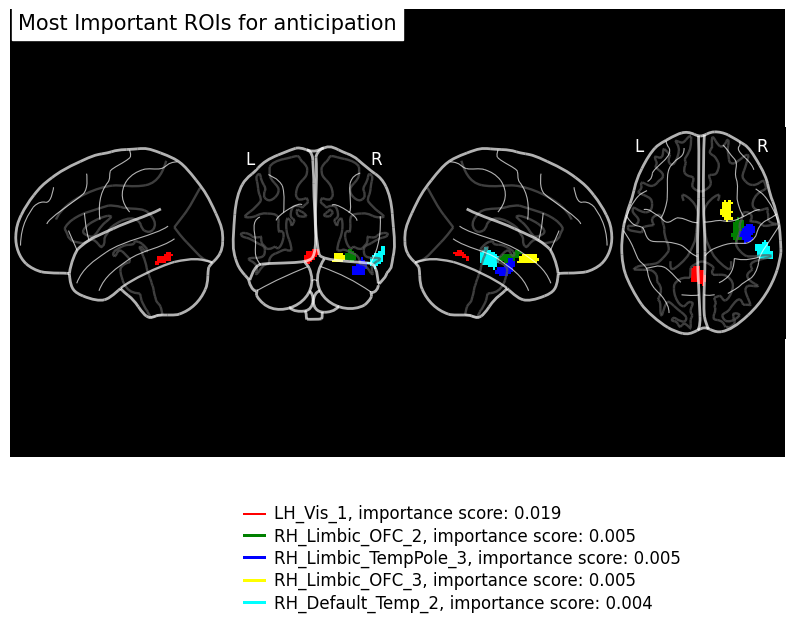

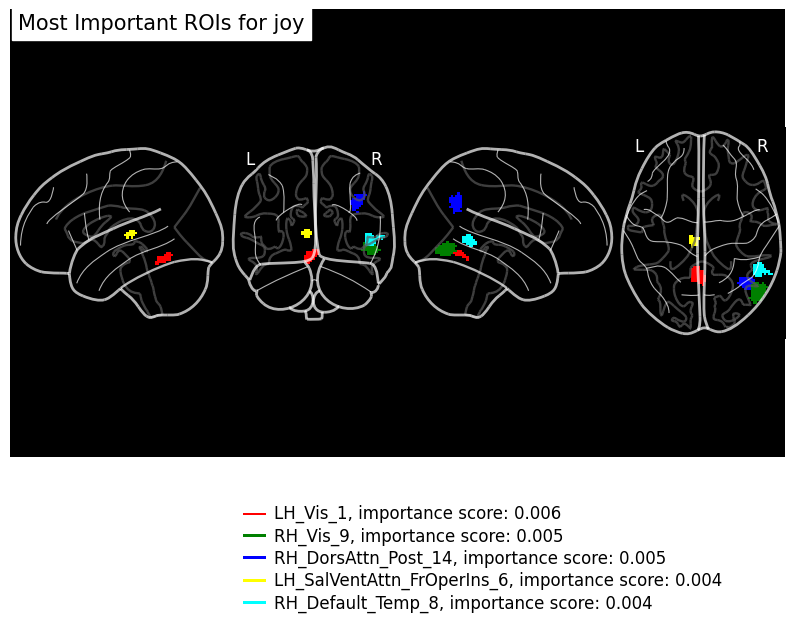

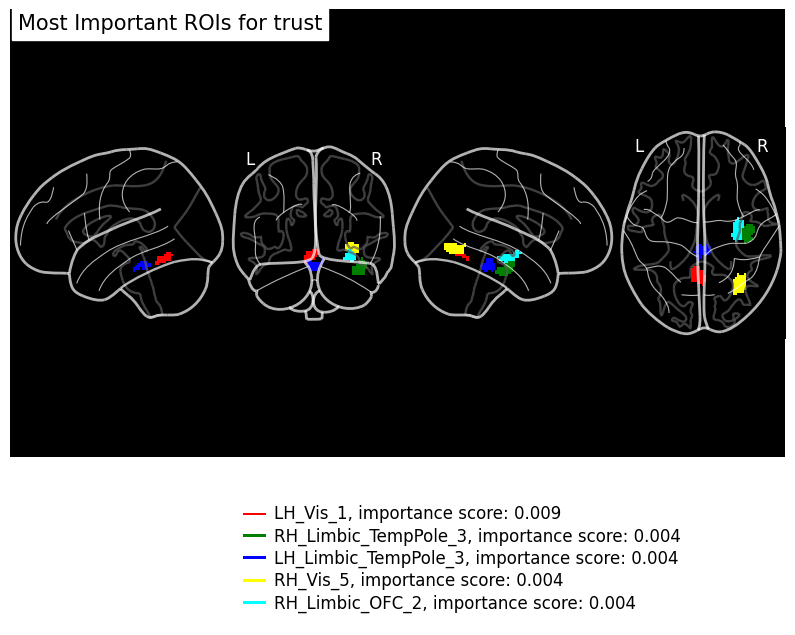

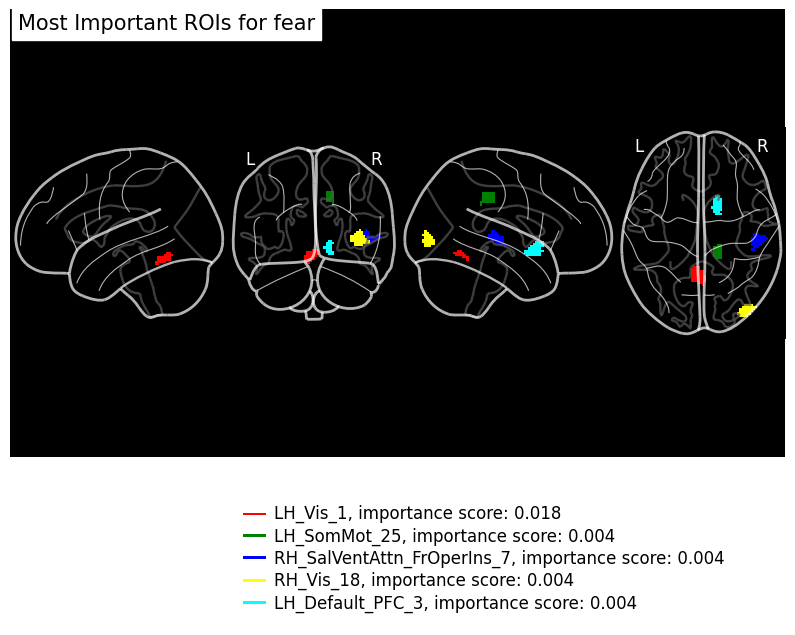

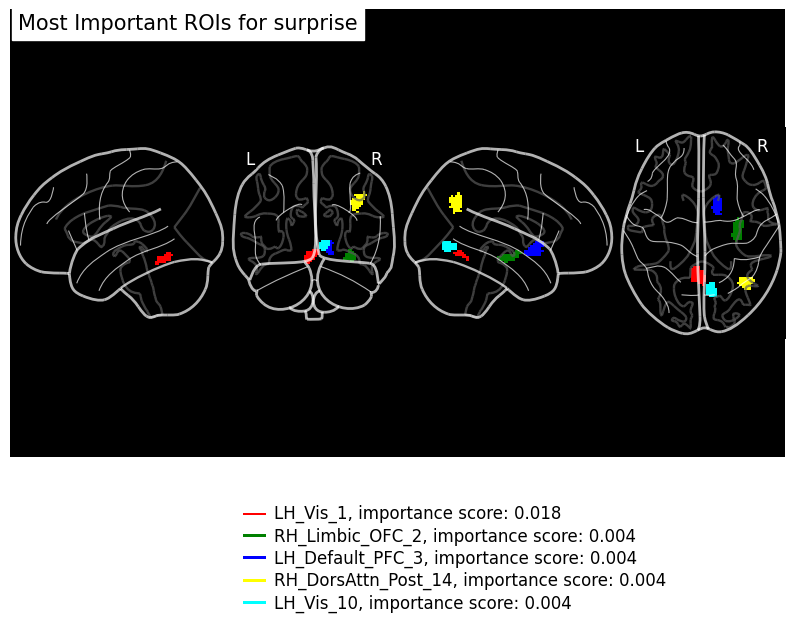

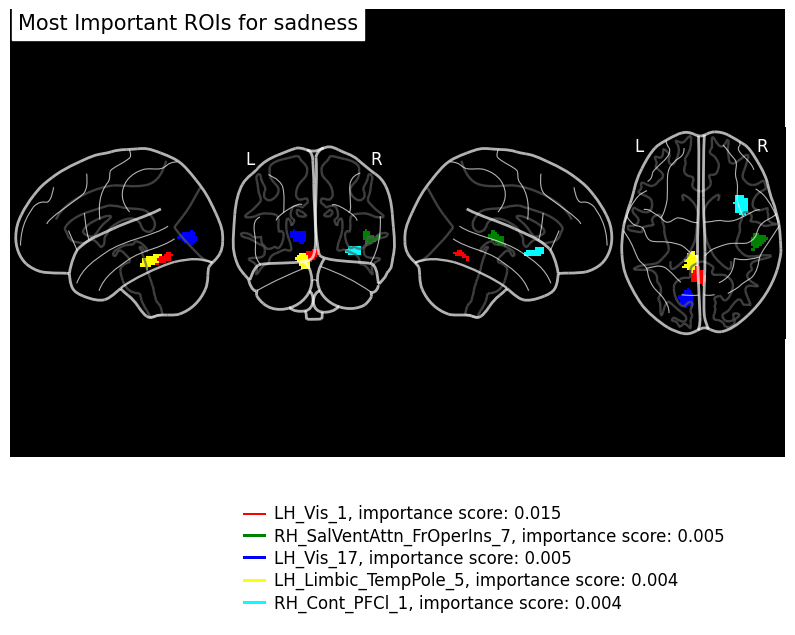

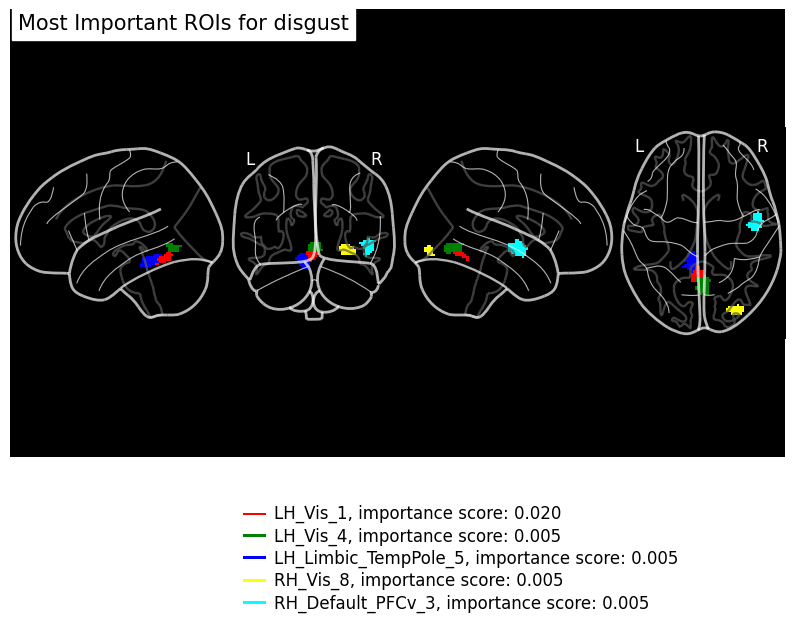

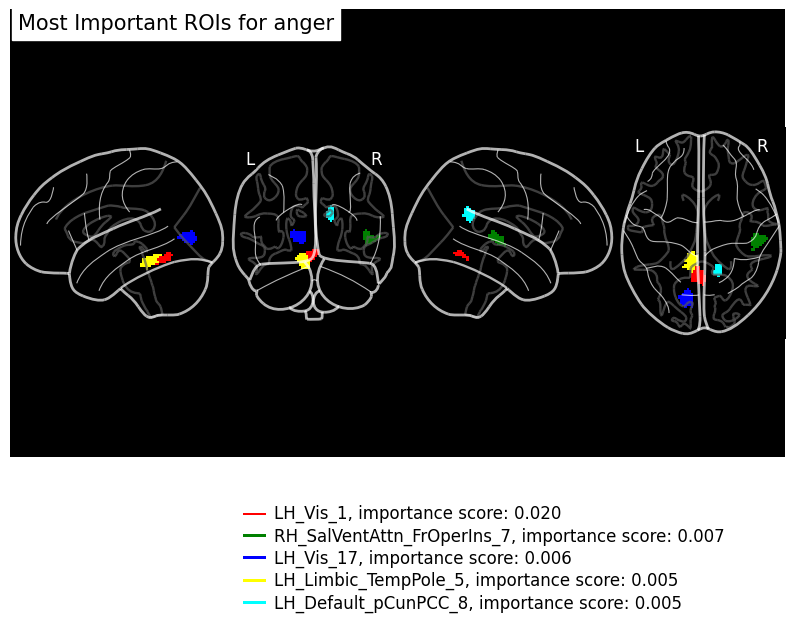

In [23]:
#print(sorted(exp.reverse_dictionary.keys()))

generate_explanations('rfr_importance.csv')

[270, 282, 161, 281, 175]
[175, 281, 161, 282, 270]
[get_dataset_dir] Dataset found in /Users/augustaasvaer/nilearn_data/schaefer_2018


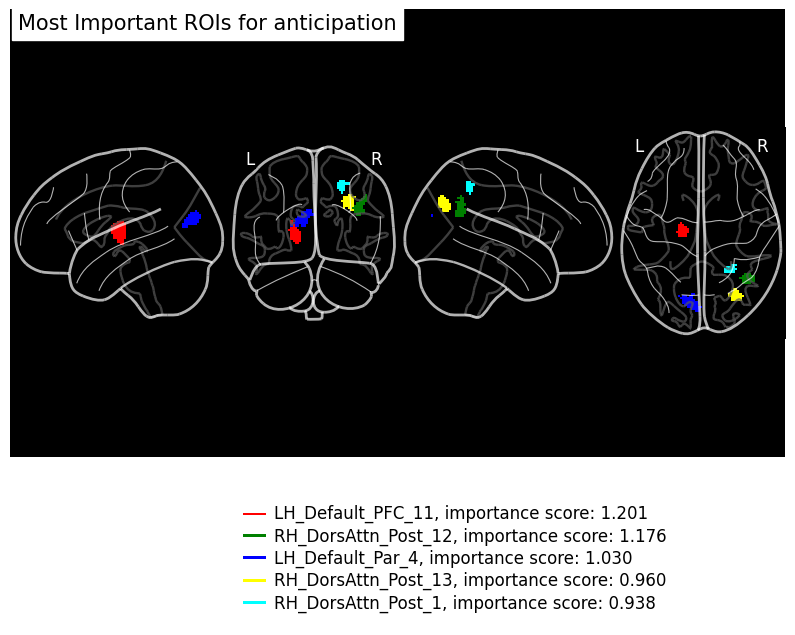

In [18]:
emotion_importance_dict

emotion_importance_dict['anticipation']


indices = sorted(range(len(emotion_importance_dict['anticipation'])), key=lambda x: emotion_importance_dict['anticipation'][x])[-5:]

print(indices)
indices = indices[::-1]
print(indices)

importances = [emotion_importance_dict['anticipation'][i] for i in indices]

exp.visualize_3d(indices, importances, 'anticipation')

In [22]:
rfr_df = pd.read_csv('rfr_importance.csv', header=1)

rfr_df.to_csv('rfr_importance.csv')

In [19]:
svr_df = pd.read_csv('svr_importance.csv', header=1)


svr_df.to_csv('svr_importance.csv')

In [ ]:
rfr_df.to_csv()

,Unnamed: 0,anticipation,joy,trust,fear,suprise,sadness,disgust,anger
0,Feature_0,-0.004907,0.004783,0.003420,-0.001652,-0.113208,0.141904,-0.006995,0.022370
1,Feature_1,0.006176,0.002335,0.003090,-0.003799,0.027273,-0.025480,0.000890,-0.003267
2,Feature_2,-0.000423,0.002543,0.000425,0.010646,-0.002336,-0.044572,0.004073,-0.015296
3,Feature_3,0.002063,-0.000030,-0.000194,-0.008470,-0.006801,-0.012692,-0.009643,-0.005512
4,Feature_4,0.001296,0.006886,0.005227,0.005845,-0.012856,-0.003660,0.002882,0.002845


In [282]:

#filepaths =['lm_importance.csv', 'lasso_importance.csv', 'ridge_importance.csv', 'svr_importance.csv', 'rfr_importance.csv']
filepaths = ['rfr_importance.csv']
rois = []

for filepath in filepaths:
    importances = pd.read_csv(filepath)
    emotion_importance_dict = {key: importances[key].to_numpy() for key in emotions}
    for emotion in emotion_importance_dict.keys():
        indices = sorted(range(len(emotion_importance_dict[emotion])), key=lambda x: emotion_importance_dict[emotion][x])[-5:]
        indices = indices[::-1]
        importances = [emotion_importance_dict[emotion][i] for i in indices]
        rois += indices
        

In [283]:
print(rois)

[0, 319, 326, 320, 367, 0, 208, 283, 101, 373, 0, 326, 120, 204, 319, 0, 55, 307, 217, 167, 0, 319, 167, 283, 9, 0, 307, 16, 122, 340, 0, 3, 122, 207, 376, 0, 307, 16, 122, 196]


In [284]:
import matplotlib.pyplot as plt

counts = np.unique(rois, return_counts=True)
counts

(array([  0,   3,   9,  16,  55, 101, 120, 122, 167, 196, 204, 207, 208,
        217, 283, 307, 319, 320, 326, 340, 367, 373, 376]),
 array([8, 1, 1, 2, 1, 1, 1, 3, 2, 1, 1, 1, 1, 1, 2, 3, 3, 1, 2, 1, 1, 1,
        1]))

In [285]:
counts


path = "../../Alice/Subjects/sub-18/sub-18_task-alice_bold_preprocessed.nii.gz"
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=400, yeo_networks=7)
labels = atlas.labels


label_counts = {labels[counts[0][i]].decode('utf-8'): counts[1][i] for i in range(len(counts[0]))}

[get_dataset_dir] Dataset found in /Users/augustaasvaer/nilearn_data/schaefer_2018


In [286]:
print(label_counts)

{'7Networks_LH_Vis_1': 8, '7Networks_LH_Vis_4': 1, '7Networks_LH_Vis_10': 1, '7Networks_LH_Vis_17': 2, '7Networks_LH_SomMot_25': 1, '7Networks_LH_SalVentAttn_FrOperIns_6': 1, '7Networks_LH_Limbic_TempPole_3': 1, '7Networks_LH_Limbic_TempPole_5': 3, '7Networks_LH_Default_PFC_3': 2, '7Networks_LH_Default_pCunPCC_8': 1, '7Networks_RH_Vis_5': 1, '7Networks_RH_Vis_8': 1, '7Networks_RH_Vis_9': 1, '7Networks_RH_Vis_18': 1, '7Networks_RH_DorsAttn_Post_14': 2, '7Networks_RH_SalVentAttn_FrOperIns_7': 3, '7Networks_RH_Limbic_OFC_2': 3, '7Networks_RH_Limbic_OFC_3': 1, '7Networks_RH_Limbic_TempPole_3': 2, '7Networks_RH_Cont_PFCl_1': 1, '7Networks_RH_Default_Temp_2': 1, '7Networks_RH_Default_Temp_8': 1, '7Networks_RH_Default_PFCv_3': 1}


In [287]:
{k: v for k, v in sorted(label_counts.items(), key=lambda item: item[1], reverse=True)}

{'7Networks_LH_Vis_1': 8,
 '7Networks_LH_Limbic_TempPole_5': 3,
 '7Networks_RH_SalVentAttn_FrOperIns_7': 3,
 '7Networks_RH_Limbic_OFC_2': 3,
 '7Networks_LH_Vis_17': 2,
 '7Networks_LH_Default_PFC_3': 2,
 '7Networks_RH_DorsAttn_Post_14': 2,
 '7Networks_RH_Limbic_TempPole_3': 2,
 '7Networks_LH_Vis_4': 1,
 '7Networks_LH_Vis_10': 1,
 '7Networks_LH_SomMot_25': 1,
 '7Networks_LH_SalVentAttn_FrOperIns_6': 1,
 '7Networks_LH_Limbic_TempPole_3': 1,
 '7Networks_LH_Default_pCunPCC_8': 1,
 '7Networks_RH_Vis_5': 1,
 '7Networks_RH_Vis_8': 1,
 '7Networks_RH_Vis_9': 1,
 '7Networks_RH_Vis_18': 1,
 '7Networks_RH_Limbic_OFC_3': 1,
 '7Networks_RH_Cont_PFCl_1': 1,
 '7Networks_RH_Default_Temp_2': 1,
 '7Networks_RH_Default_Temp_8': 1,
 '7Networks_RH_Default_PFCv_3': 1}

In [306]:
decoded_labels = [el.decode('utf-8') for el in labels]
decoded_labels = [el[10:] for el in decoded_labels]
rfr_df = pd.read_csv('lm_importance.csv')

In [307]:
rfr_df.head()


,Unnamed: 0,anticipation,joy,trust,fear,suprise,sadness,disgust,anger
0,0,-0.517236,0.222078,0.036934,-0.438433,-0.769556,0.426929,-0.153246,0.234134
1,1,0.037785,-0.127218,0.054465,0.139487,0.004324,0.245393,0.007591,0.078428
2,2,0.520876,0.202606,0.007396,0.232021,0.065145,-0.336236,0.030154,-0.133033
3,3,-0.237395,0.083297,0.004841,-0.213373,-0.194745,0.019267,-0.066494,0.025474
4,4,0.248409,0.148899,0.121721,0.106764,0.067877,0.168272,-0.006994,0.012835


In [308]:
rfr_df =rfr_df[rfr_df.columns[-8:]]




In [309]:
rfr_df['labels'] = decoded_labels
rfr_df = rfr_df.set_index('labels')
rfr_df = rfr_df.sort_index()




In [310]:
import seaborn as sn



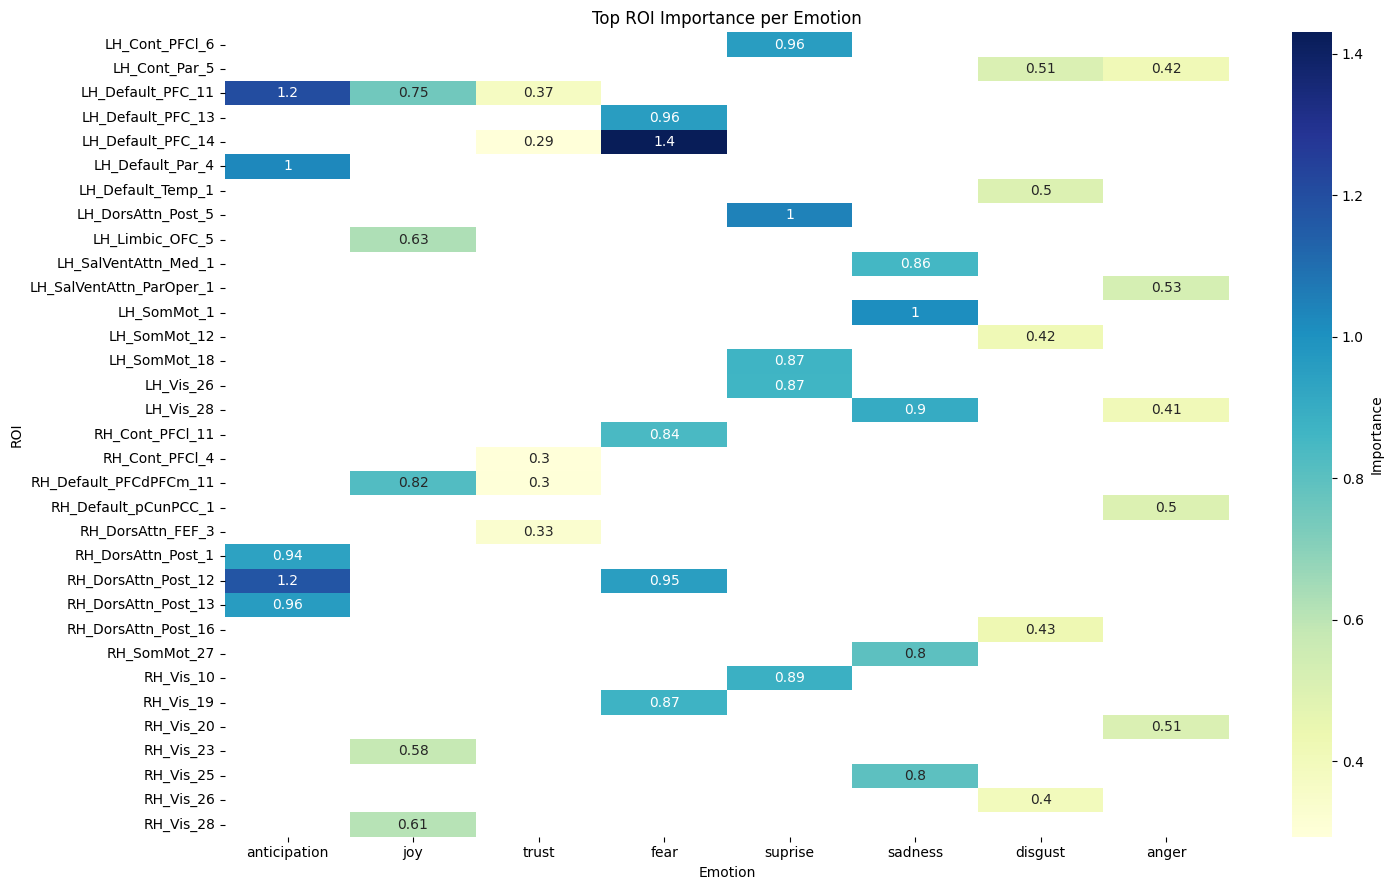

In [314]:
top_rois_per_emotion = {
    emotion: rfr_df[emotion].sort_values(ascending=False).head(5)
    for emotion in rfr_df.columns
}

top_df = pd.DataFrame(top_rois_per_emotion)


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 9))
sns.heatmap(top_df, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Importance'})
plt.title("Top ROI Importance per Emotion")
plt.xlabel("Emotion")
plt.ylabel("ROI")
plt.tight_layout()
plt.show()


In [312]:
top_df

,anticipation,joy,trust,fear,suprise,sadness,disgust,anger
labels,,,,,,,,
LH_Cont_PFCl_6,NaN,NaN,NaN,NaN,0.957839,NaN,NaN,NaN
LH_Cont_Par_5,NaN,NaN,NaN,NaN,NaN,NaN,0.508308,0.416988
LH_Default_PFC_11,1.200893,0.751226,0.374428,NaN,NaN,NaN,NaN,NaN
LH_Default_PFC_13,NaN,NaN,NaN,0.955341,NaN,NaN,NaN,NaN
LH_Default_PFC_14,NaN,NaN,0.293491,1.430383,NaN,NaN,NaN,NaN
LH_Default_Par_4,1.029981,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LH_Default_Temp_1,NaN,NaN,NaN,NaN,NaN,NaN,0.498403,NaN
LH_DorsAttn_Post_5,NaN,NaN,NaN,NaN,1.045800,NaN,NaN,NaN
LH_Limbic_OFC_5,NaN,0.629646,NaN,NaN,NaN,NaN,NaN,NaN


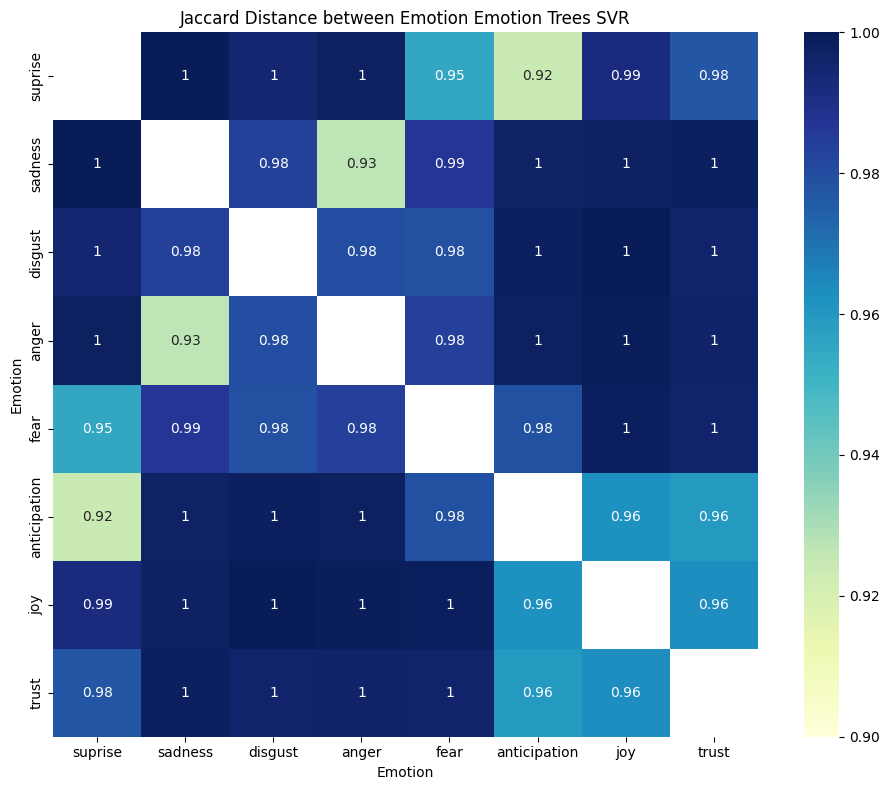

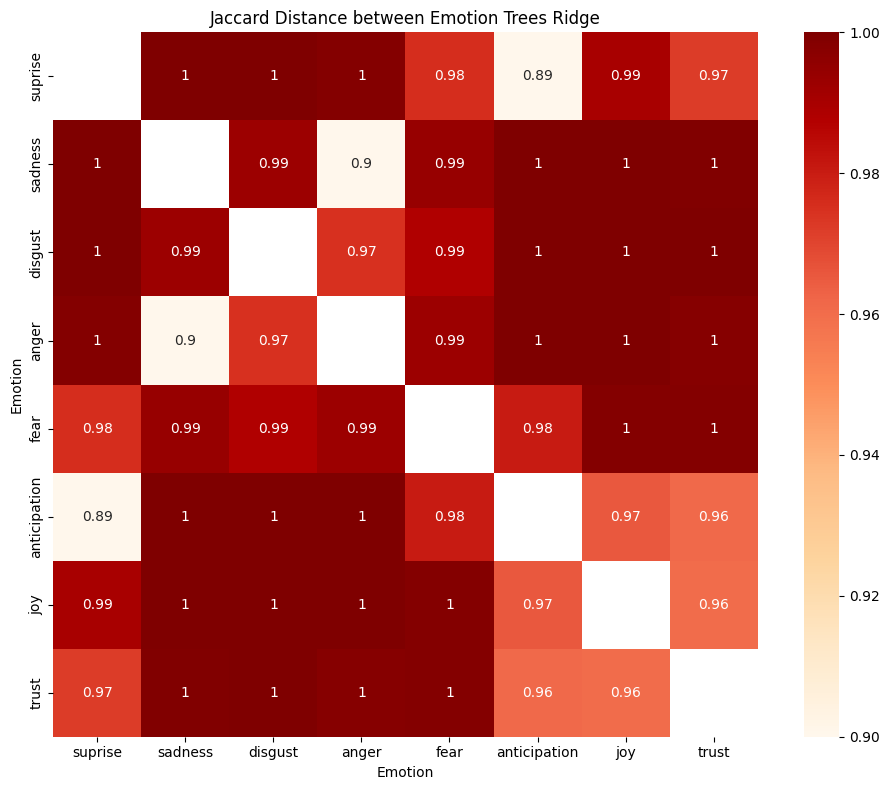

In [413]:
import seaborn as sns
import matplotlib.pyplot as plt

jaccard_df_svr = pd.read_csv('7N_jackard_distance_matrix_SVM.csv')

jaccard_df_svr.head()
jaccard_df_svr = jaccard_df_svr.set_index('Unnamed: 0')

plt.figure(figsize=(10, 8))
sns.heatmap(jaccard_df_svr, annot=True, cmap="YlGnBu", square=True, vmin=0.9, vmax=1.0)
plt.title("Jaccard Distance between Emotion Emotion Trees SVR")
plt.xlabel("Emotion")
plt.ylabel("Emotion")
plt.tight_layout()
plt.show()


import seaborn as sns
import matplotlib.pyplot as plt

jaccard_df_ridge = pd.read_csv('7N_jackard_distance_matrix_Ridge.csv')

jaccard_df_ridge.head()
jaccard_df_ridge = jaccard_df_ridge.set_index('Unnamed: 0')

plt.figure(figsize=(10, 8))
sns.heatmap(jaccard_df_ridge, annot=True, cmap="OrRd", square=True, vmin=0.9, vmax=1.0)
plt.title("Jaccard Distance between Emotion Trees Ridge")
plt.xlabel("Emotion")
plt.ylabel("Emotion")
plt.tight_layout()
plt.show()

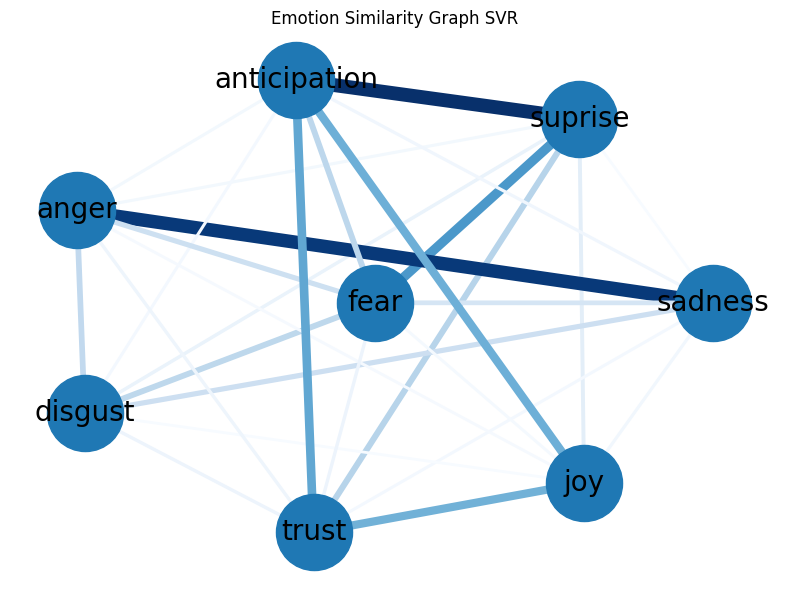

In [383]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

G = nx.Graph()

for i in jaccard_df_svr.index:
    for j in jaccard_df_svr.columns:
        if i != j and not np.isnan(jaccard_df_svr.loc[i, j]):
            G.add_edge(i, j, weight=jaccard_df_svr.loc[i, j])

pos = nx.spring_layout(G, seed=42)

edges = G.edges(data=True)
raw_weights = np.array([1-d['weight'] for (_, _, d) in edges])

min_w = raw_weights.min()
max_w = raw_weights.max()
scaled_weights = (raw_weights - min_w) / (max_w - min_w + 1e-8) 

edge_widths = 1 + 4 * scaled_weights

fig, ax = plt.subplots(figsize=(8, 6))

fig.patch.set_facecolor('black')  
ax.set_facecolor('black')       

nx.draw(
    G,
    pos,
    ax=ax,
    with_labels=True,
    width=edge_widths * 2,
    edge_color=scaled_weights,
    edge_cmap=plt.cm.Blues,
    node_size=3000,
    font_size=20,
)

plt.title("Emotion Similarity Graph SVR")
plt.tight_layout()
plt.show()

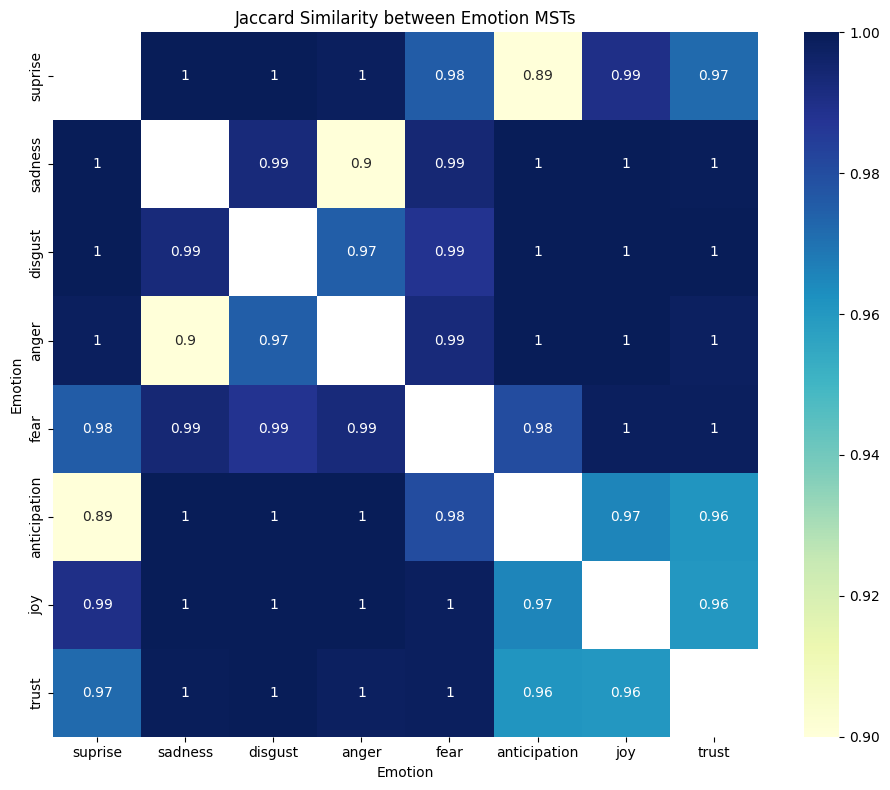

In [368]:
import seaborn as sns
import matplotlib.pyplot as plt

jaccard_df_ridge = pd.read_csv('7N_jackard_distance_matrix_Ridge.csv')

jaccard_df_ridge.head()
jaccard_df_ridge = jaccard_df_ridge.set_index('Unnamed: 0')

plt.figure(figsize=(10, 8))
sns.heatmap(jaccard_df_ridge, annot=True, cmap="YlGnBu", square=True, vmin=0.9, vmax=1.0)
plt.title("Jaccard Similarity between Emotion MSTs")
plt.xlabel("Emotion")
plt.ylabel("Emotion")
plt.tight_layout()
plt.show()

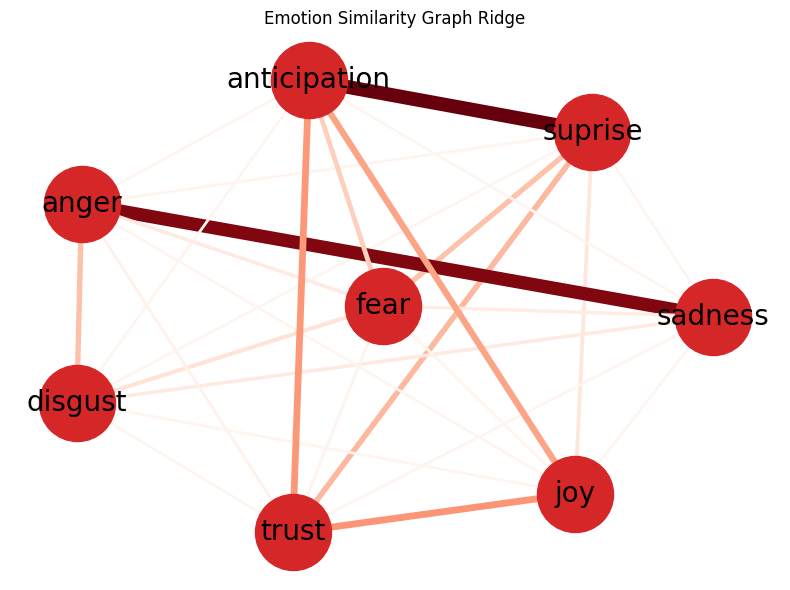

In [411]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

G = nx.Graph()

for i in jaccard_df_ridge.index:
    for j in jaccard_df_ridge.columns:
        if i != j and not np.isnan(jaccard_df_ridge.loc[i, j]):
            G.add_edge(i, j, weight=jaccard_df_ridge.loc[i, j])

pos = nx.spring_layout(G, seed=42)

edges = G.edges(data=True)
raw_weights = np.array([1-d['weight'] for (_, _, d) in edges])

min_w = raw_weights.min()
max_w = raw_weights.max()
scaled_weights = (raw_weights - min_w) / (max_w - min_w + 1e-8) 

edge_widths = 1 + 4 * scaled_weights

fig, ax = plt.subplots(figsize=(8, 6))

fig.patch.set_facecolor('black')  
ax.set_facecolor('black')       

nx.draw(
    G,
    pos,
    ax=ax,
    with_labels=True,
    width=edge_widths * 2,
    node_color='tab:red',
    edge_color=scaled_weights,
    edge_cmap=plt.cm.Reds,
    node_size=3000,
    font_size=20,
)

plt.title("Emotion Similarity Graph Ridge")
plt.tight_layout()
plt.show()

95% Confidence Interval for the permutation scores: [-0.1085, -0.0584]


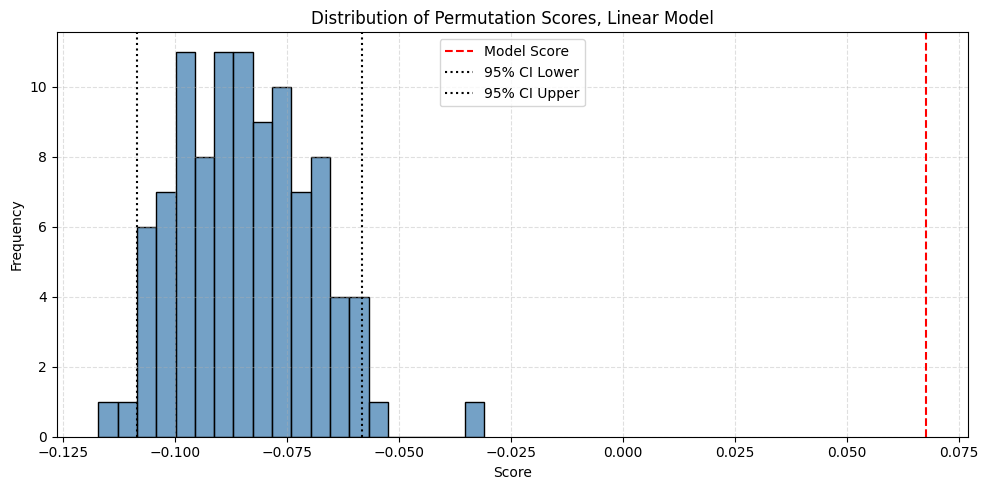

In [427]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_score = 0.0677
perm_perf = np.array([-0.08584964454926938, -0.0887810852973955, -0.07505430777029032, -0.09608120352214367, -0.07641923574667028, -0.08336702604926502, -0.06701791577443589, -0.06074637667204619, -0.0894566635754005, -0.10460946390512837, -0.09654356057084879, -0.06266274112173009, -0.07127206427848656, -0.0814917596364571, -0.0651521136361006, -0.09169403119433603, -0.05871650704673295, -0.10111435509072009, -0.08932025258685869, -0.07938830991150261, -0.08907881999630377, -0.09773893101410305, -0.07727116807958209, -0.09766388480362431, -0.0832697331832335, -0.103653021160339, -0.0939641293908752, -0.0897209108724521, -0.06452131633525202, -0.07866776446286788, -0.09501202996713856, -0.09112240458034007, -0.0803744570612949, -0.10017944248713256, -0.0965537878848487, -0.08376805434450152, -0.08581218927405432, -0.07096153350361684, -0.11093604652082045, -0.08347870748510125, -0.0936741187558322, -0.08804312210977236, -0.07740049213302294, -0.08577892388954897, -0.06694354290657228, -0.06659697112571306, -0.08158601304252355, -0.10068466461420289, -0.10117309191143553, -0.09524510374168882, -0.09006856892026815, -0.0833695640623322, -0.07764807409876401, -0.07569483293168905, -0.07242135674662206, -0.06656498771042826, -0.09748812774925936, -0.07597545276527903, -0.09428673527966464, -0.0882547611820339, -0.10852166678990383, -0.08472605944699618, -0.09643696100704507, -0.08027479784921343, -0.058134073538811254, -0.11717704493947606, -0.08660294027790486, -0.10411758390307085, -0.10396073806368053, -0.09780583722023964, -0.07358332922555919, -0.08027169650111288, -0.06421003074463044, -0.0923315263239298, -0.10434020776548375, -0.08822304506546333, -0.06642721376992194, -0.08036468155536516, -0.05518055894468751, -0.06904167995052338, -0.05962531816175906, -0.07968388231039666, -0.09679770539463625, -0.06976992340342852, -0.07477410761887027, -0.0761027473902707, -0.07143843270331462, -0.0858356686198998, -0.09885930819869015, -0.10853727583833445, -0.06630875713885215, -0.07663907242804699, -0.09730191926564702, -0.09328714846809291, -0.06750027371765824, -0.08792004098434475, -0.07027394350448246, -0.10448981614655545, -0.10756773863507335, -0.03097769517288368])


ci_lower = np.percentile(perm_perf, 2.5)
ci_upper = np.percentile(perm_perf, 97.5)

print(f"95% Confidence Interval for the permutation scores: [{ci_lower:.4f}, {ci_upper:.4f}]")

plt.figure(figsize=(10, 5))
sns.histplot(perm_perf, kde=False, bins=20, color="steelblue")

plt.axvline(x=model_score, color='red', linestyle='dashed', label='Model Score')
plt.axvline(x=ci_lower, color='black', linestyle='dotted', label='95% CI Lower')
plt.axvline(x=ci_upper, color='black', linestyle='dotted', label='95% CI Upper')

plt.title("Distribution of Permutation Scores, Linear Model")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



95% Confidence Interval for the permutation scores: [-0.0308, -0.0063]


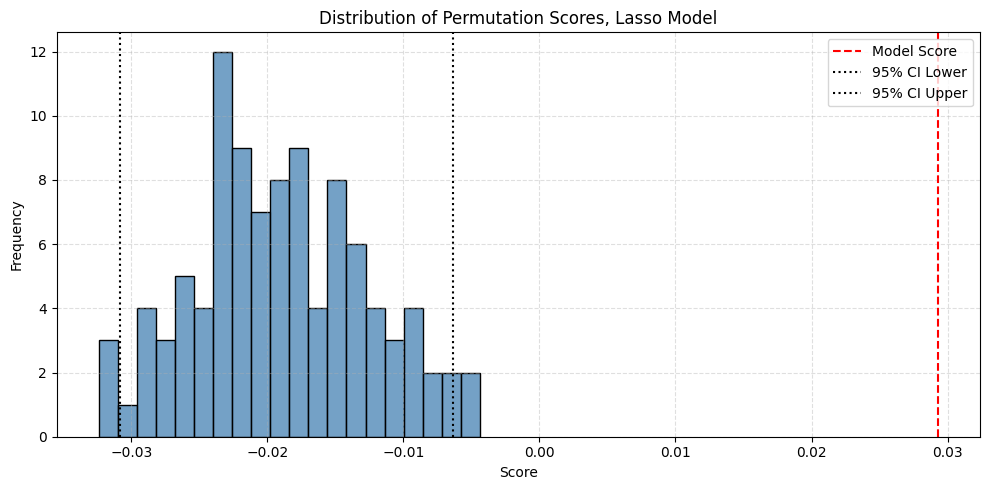

In [428]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_score = 0.0293
perm_perf = np.array([-0.019730769297572073, -0.026115484753538254, -0.02597138006940078, -0.00953338852905021, -0.03182844296240353, -0.008010259553296803, -0.023526333993064877, -0.013949406861415811, -0.012154747987797865, -0.01745452663107394, -0.014959323356364684, -0.014321876801864017, -0.01914344794620451, -0.023873930031189705, -0.008589250780013782, -0.032159481655375605, -0.0090650453745766, -0.02821190094001244, -0.015134173249547661, -0.0182944412165833, -0.020717398337226772, -0.00973942507920679, -0.024467482247816447, -0.020614945831824633, -0.01733864806679833, -0.02345194393426564, -0.024669479915778447, -0.018166344003958168, -0.027001775885590967, -0.012754816316015188, -0.01611652579972883, -0.03238129094448641, -0.015906703882388268, -0.017861531220223492, -0.021869658995250535, -0.012837179062720111, -0.004381942573752226, -0.016654987432089763, -0.010103822935577891, -0.01758319184526702, -0.022444743488756358, -0.014573639962989896, -0.02084604212988514, -0.019454026476462966, -0.013484450121390434, -0.020214828631026388, -0.020810660968599876, -0.023414161484251406, -0.0214988375330189, -0.0073729695824158725, -0.02133405779569597, -0.017382304769643434, -0.010616323028151242, -0.01876950895280524, -0.014131357925433505, -0.0193182172240942, -0.028890629256297456, -0.02330325407056083, -0.029722180042140584, -0.016927601749880894, -0.021840961372380258, -0.014732396176706908, -0.021666728404663743, -0.018462896753562066, -0.02698120621795927, -0.019611199869352947, -0.011285016918453142, -0.006345106089624977, -0.014456168200198918, -0.01332747150513551, -0.026638133463567415, -0.023663127308677923, -0.027708901668560076, -0.023426710019147673, -0.021646238090569203, -0.01453733324708277, -0.00629344981049107, -0.022953215378024222, -0.004818553638754622, -0.022543628911631308, -0.024305912012957148, -0.020767516099086863, -0.028998353703935775, -0.012379358366266205, -0.022768346958465052, -0.025050938178880156, -0.026660736822698178, -0.02839497526906032, -0.023650745819698366, -0.018785964464729105, -0.023682358387620978, -0.013806147549681957, -0.017182633427564847, -0.02312029591166731, -0.012143228994358074, -0.01543900732543077, -0.021488023630943986, -0.01727441490236281, -0.020676952700610263, -0.0266396689843644])


ci_lower = np.percentile(perm_perf, 2.5)
ci_upper = np.percentile(perm_perf, 97.5)

print(f"95% Confidence Interval for the permutation scores: [{ci_lower:.4f}, {ci_upper:.4f}]")

plt.figure(figsize=(10, 5))
sns.histplot(perm_perf, kde=False, bins=20, color="steelblue")

plt.axvline(x=model_score, color='red', linestyle='dashed', label='Model Score')
plt.axvline(x=ci_lower, color='black', linestyle='dotted', label='95% CI Lower')
plt.axvline(x=ci_upper, color='black', linestyle='dotted', label='95% CI Upper')

plt.title("Distribution of Permutation Scores, Lasso Model")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



95% Confidence Interval for the permutation scores: [-0.1109, -0.0600]


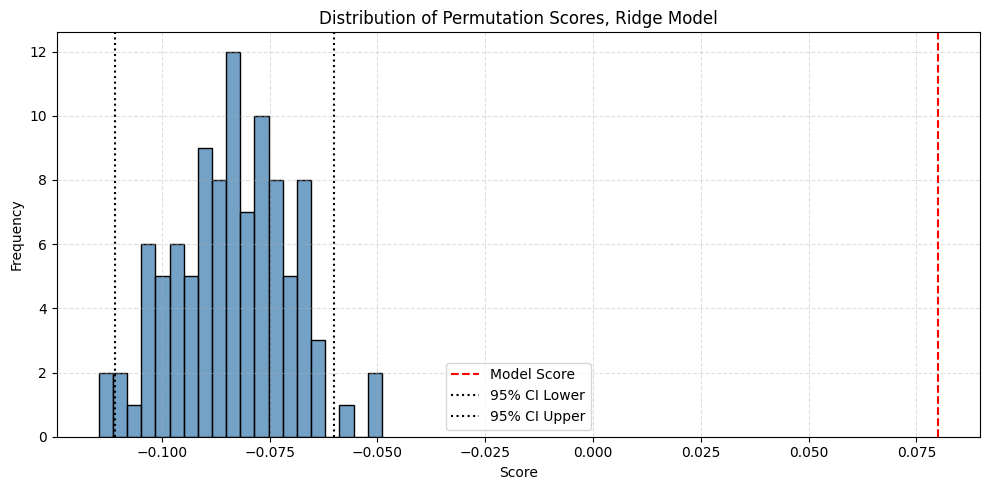

In [429]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_score = 0.0800
perm_perf = np.array([-0.07814747001081854, -0.09761117230711044, -0.07014468395281875, -0.08225578611103151, -0.08359739891682402, -0.06802386010247327, -0.06936143570260705, -0.09028661906599464, -0.11458528537519552, -0.07277515836763843, -0.05713664086660539, -0.07630205263799195, -0.08203534835649465, -0.0630946183637553, -0.08079102449006309, -0.0973375613591381, -0.06378206681854665, -0.09940991566755383, -0.10279690955160334, -0.09646966526255926, -0.06826801501459875, -0.09664189873429513, -0.07489204358141102, -0.09908047100145728, -0.08688023229567751, -0.10123870096043186, -0.08404189021395075, -0.07559758192478949, -0.09129794988272805, -0.07694193995036874, -0.07871937784484229, -0.09156048857379859, -0.09134124971906307, -0.06544700801518258, -0.11101522634212418, -0.07442751433604197, -0.10167962724906932, -0.09207877603158376, -0.09804949817127456, -0.10381547361780108, -0.09397513379143416, -0.09634254069615777, -0.06931108081355938, -0.09101286643307466, -0.08399433068723403, -0.06819363096170739, -0.10012738925995879, -0.0878610356988348, -0.08520310418271385, -0.06791770041791906, -0.06567965198374975, -0.07376284417900689, -0.07655992813118617, -0.07921981883223275, -0.09245358864632272, -0.08071393754560072, -0.06441686409260564, -0.07447402423226734, -0.08291786265503248, -0.07741069622844321, -0.09149069450823036, -0.10290590121386656, -0.11320952243191776, -0.07471616275708323, -0.07701712149105716, -0.08904474749610189, -0.08925457221406763, -0.08331200657117388, -0.04953423409303004, -0.08490403012946088, -0.08677086526898023, -0.08701881009945042, -0.09408949110364312, -0.08227186308760473, -0.09121493236771058, -0.08434190190138563, -0.10460383820840768, -0.08089671165883583, -0.08588538998002795, -0.08357650456038851, -0.10372982870366595, -0.08787845121053933, -0.06775386030676298, -0.0693715418398256, -0.04897786083481542, -0.10646630085180517, -0.11070617786335696, -0.07785139814581432, -0.07521080855171539, -0.09467950864729086, -0.07931390068601235, -0.06889498695713406, -0.08828485741947162, -0.07211559622934519, -0.0773623672175622, -0.08300366318362107, -0.07921461296707333, -0.1004395346276192, -0.07754778114432054, -0.06828185024341094])


ci_lower = np.percentile(perm_perf, 2.5)
ci_upper = np.percentile(perm_perf, 97.5)

print(f"95% Confidence Interval for the permutation scores: [{ci_lower:.4f}, {ci_upper:.4f}]")

plt.figure(figsize=(10, 5))
sns.histplot(perm_perf, kde=False, bins=20, color="steelblue")

plt.axvline(x=model_score, color='red', linestyle='dashed', label='Model Score')
plt.axvline(x=ci_lower, color='black', linestyle='dotted', label='95% CI Lower')
plt.axvline(x=ci_upper, color='black', linestyle='dotted', label='95% CI Upper')

plt.title("Distribution of Permutation Scores, Ridge Model")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.model_selection import permutation_test_score
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import time
from sklearn.metrics import mean_squared_error, r2_score


emotions = ['anticipation', 'joy', 'trust', 'fear', 'suprise', 'sadness', 'disgust', 'anger']



df = pd.read_csv('/cluster/home/augustsa/demonstrasjon/roi/all_networks.csv')

X = df[df.columns[:-8]]
y = df[df.columns[-8:]]

stratify_col = X['subject_no'].astype(str) + '_' + X['time_quantization'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=stratify_col
)

X_train_feat = X_train.iloc[:, :400]
X_test_feat = X_test.iloc[:, :400]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled = scaler.transform(X_test_feat)



for i, emotion in enumerate(emotions):
    y_target = y_train.iloc[:, i]  

    svr = SVR(kernel='rbf', C=1, epsilon=0.01, gamma=1)

    score, perm_scores, p_value = permutation_test_score(
        svr,
        X_train_scaled,
        y_target,
        scoring="r2",        
        cv=5,
        n_permutations=100,
        n_jobs=-1,
        random_state=42
    )
    print(f"## P testing for emotion:{emotion}")
    print(f"Observed R²: {score:.3f}")
    print(f"Permutation p-value: {p_value:.4f}")
    print(f"Perm Scores: {perm_scores}")
    print('\n\n')

In [ ]:
from sklearn.model_selection import permutation_test_score
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import time
from sklearn.metrics import mean_squared_error, r2_score


emotions = ['anticipation', 'joy', 'trust', 'fear', 'suprise', 'sadness', 'disgust', 'anger']



df = pd.read_csv('/cluster/home/augustsa/demonstrasjon/roi/all_networks.csv')

X = df[df.columns[:-8]]
y = df[df.columns[-8:]]

stratify_col = X['subject_no'].astype(str) + '_' + X['time_quantization'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=stratify_col
)

X_train_feat = X_train.iloc[:, :400]
X_test_feat = X_test.iloc[:, :400]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled = scaler.transform(X_test_feat)



for i, emotion in enumerate(emotions):
    y_target = y_train.iloc[:, i]  

    svr = SVR(kernel='linear', C=0.01, epsilon=0.01, gamma='scale')

    score, perm_scores, p_value = permutation_test_score(
        svr,
        X_train_scaled,
        y_target,
        scoring="r2",        
        cv=5,
        n_permutations=100,
        n_jobs=-1,
        random_state=42
    )
    print(f"## P testing for emotion:{emotion}")
    print(f"Observed R²: {score:.3f}")
    print(f"Permutation p-value: {p_value:.4f}")
    print(f"Perm Scores: {perm_scores}")
    print('\n\n')

In [ ]:
from sklearn.model_selection import permutation_test_score
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score


from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.multioutput import MultiOutputRegressor



emotions = ['anticipation', 'joy', 'trust', 'fear', 'suprise', 'sadness', 'disgust', 'anger']



df = pd.read_csv('/cluster/home/augustsa/demonstrasjon/roi/all_networks.csv')

X = df[df.columns[:-8]]
y = df[df.columns[-8:]]

stratify_col = X['subject_no'].astype(str) + '_' + X['time_quantization'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=stratify_col
)

X_train_feat = X_train.iloc[:, :400]
X_test_feat = X_test.iloc[:, :400]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled = scaler.transform(X_test_feat)





from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np

model = MultiOutputRegressor(LinearRegression())
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
true_score = r2_score(y_test, y_pred, multioutput='uniform_average')

n_permutations = 100
perm_scores = []

for _ in range(n_permutations):
    y_perm = np.random.permutation(y_train)
    model.fit(X_train, y_perm)
    y_perm_pred = model.predict(X_test)
    score = r2_score(y_test, y_perm_pred, multioutput='uniform_average')
    perm_scores.append(score)

p_val = (np.sum(np.array(perm_scores) >= true_score) + 1) / (n_permutations + 1)

print(f"## LINEAR MODEL ##")
print("p-value:", p_val)
print(f"p-scores for permuations: {perm_scores}")
print("\n\n")

model = MultiOutputRegressor(Lasso(alpha=0.0001))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
true_score = r2_score(y_test, y_pred, multioutput='uniform_average')

perm_scores = []

for _ in range(n_permutations):
    y_perm = np.random.permutation(y_train)
    model.fit(X_train, y_perm)
    y_perm_pred = model.predict(X_test)
    score = r2_score(y_test, y_perm_pred, multioutput='uniform_average')
    perm_scores.append(score)

p_val = (np.sum(np.array(perm_scores) >= true_score) + 1) / (n_permutations + 1)

print(f"## LASSO MODEL ##")
print("p-value:", p_val)
print(f"p-scores for permuations: {perm_scores}")
print("\n\n")

model = MultiOutputRegressor(Ridge(alpha=1.7575106248547894))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
true_score = r2_score(y_test, y_pred, multioutput='uniform_average')

perm_scores = []

for _ in range(n_permutations):
    y_perm = np.random.permutation(y_train)
    model.fit(X_train, y_perm)
    y_perm_pred = model.predict(X_test)
    score = r2_score(y_test, y_perm_pred, multioutput='uniform_average')
    perm_scores.append(score)

p_val = (np.sum(np.array(perm_scores) >= true_score) + 1) / (n_permutations + 1)

print(f"## RIDGE MODEL ##")
print("p-value:", p_val)
print(f"p-scores for permuations: {perm_scores}")
print("\n\n")

In [ ]:
import numpy as np
import os
import pandas as pd
import scipy.io
from sklearn.preprocessing import minmax_scale, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso, Ridge
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import time

start_time = time.time()
print("Start Time:", time.strftime("%H:%M:%S", time.localtime(start_time)))


df = pd.read_csv('/cluster/home/augustsa/demonstrasjon/roi/all_networks.csv')

X = df[df.columns[:-8]]
y = df[df.columns[-8:]]

stratify_col = X['subject_no'].astype(str) + '_' + X['time_quantization'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=stratify_col
)

X_train = X_train.iloc[:, :400]
X_test = X_test.iloc[:, :400]


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



base_rf = RandomForestRegressor(n_estimators=2000, random_state=42, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', max_depth=None, n_jobs=4)

print("Training Random Forest model...")
base_rf.fit(X_train, y_train)



y_pred = base_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred, multioutput='uniform_average')

print("RFR Model Performance:")
print("Test Mean Squared Error (MSE):", mse)
print("Test R^2 Score:", r2)

y_pred_train = base_rf.predict(X_train)

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train, multioutput='uniform_average')

print("RFR model preformance, train: ")
print("Train mean squared Error (MSE):", mse_train)
print("Train R^2 Score:", r2_train)

true_r2 = r2

permuted_r2_scores = []

print("\nRunning permutation test with 100 permutations...")
for i in range(100):
    y_train_permuted = y_train.apply(np.random.permutation)

    permuted_model = RandomForestRegressor(
        n_estimators=2000,
        random_state=42,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        max_depth=None,
        n_jobs=4
    )
    permuted_model.fit(X_train, y_train_permuted)

    y_permuted_pred = permuted_model.predict(X_test)
    r2_perm = r2_score(y_test, y_permuted_pred, multioutput='uniform_average')

    permuted_r2_scores.append(r2_perm)


num_extreme = sum(r2_perm >= true_r2 for r2_perm in permuted_r2_scores)
p_value = (num_extreme + 1) / (100 + 1)

print("\nPermutation Test Results:")
print(f"True R^2 Score: {true_r2:.4f}")
print(f"Empirical p-value: p = {p_value:.4f}")



In [ ]:
import numpy as np
import os
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

start_time = time.time()
print("Start Time:", time.strftime("%H:%M:%S", time.localtime(start_time)))

data_path = '/cluster/home/augustsa/demonstrasjon/roi/SalVentAttn_Vis_excluded.csv'

emotions = ['anticipation', 'joy', 'trust', 'fear', 'suprise', 'sadness', 'disgust', 'anger']

df = pd.read_csv(data_path)
X = df[df.columns[:-8]]
y = df[df.columns[-8:]]

stratify_col = X['subject_no'].astype(str) + '_' + X['time_quantization'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=stratify_col
)

X_train = X_train.iloc[:, :292]
X_test = X_test.iloc[:, :292]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


y_pred_test_all = []
y_pred_train_all = []

for i, emotion in enumerate(emotions):
    print(f"\nTraining Random Forest for emotion: {emotion}")

    rf = RandomForestRegressor(
        n_estimators=2000,
        random_state=42,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        max_depth=None,
        n_jobs=4
    )

    rf.fit(X_train, y_train.iloc[:, i])

    y_pred_test = rf.predict(X_test)
    y_pred_train = rf.predict(X_train)

    y_pred_test_all.append(y_pred_test)
    y_pred_train_all.append(y_pred_train)

y_pred_test_all = np.vstack(y_pred_test_all).T
y_pred_train_all = np.vstack(y_pred_train_all).T

mse_test_real = mean_squared_error(y_test, y_pred_test_all)
r2_test_real = r2_score(y_test, y_pred_test_all, multioutput='uniform_average')

mse_train_real = mean_squared_error(y_train, y_pred_train_all)
r2_train_real = r2_score(y_train, y_pred_train_all, multioutput='uniform_average')

print("\n")
print("### Random Forest Model Performance ###")
print(f"Test MSE: {mse_test_real:.4f}")
print(f"Test R²: {r2_test_real:.4f}")
print(f"Train MSE: {mse_train_real:.4f}")
print(f"Train R²: {r2_train_real:.4f}")


n_permutations = 100
permuted_mse = []
permuted_r2 = []

print("\nStarting permutation testing...")

for p in range(n_permutations):
    y_train_permuted = y_train.sample(frac=1.0, replace=False, random_state=p).reset_index(drop=True)

    y_pred_test_perm = []

    for i, emotion in enumerate(emotions):
        rf = RandomForestRegressor(
            n_estimators=2000,
            random_state=42,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features='sqrt',
            max_depth=None,
            n_jobs=4
        )
        rf.fit(X_train, y_train_permuted.iloc[:, i])
        y_pred = rf.predict(X_test)
        y_pred_test_perm.append(y_pred)

    y_pred_test_perm = np.vstack(y_pred_test_perm).T

    mse_perm = mean_squared_error(y_test, y_pred_test_perm)
    r2_perm = r2_score(y_test, y_pred_test_perm, multioutput='uniform_average')

    permuted_mse.append(mse_perm)
    permuted_r2.append(r2_perm)

    if p % 10 == 0:
        print(f"Permutation {p+1}/{n_permutations} - MSE: {mse_perm:.4f}, R²: {r2_perm:.4f}")


permuted_mse = np.array(permuted_mse)
permuted_r2 = np.array(permuted_r2)

print("\n")

print("### Permutation Test Results ###")
print(f"Mean Permuted Test MSE: {permuted_mse.mean():.4f} (Real: {mse_test_real:.4f})")
print(f"Mean Permuted Test R²: {permuted_r2.mean():.4f} (Real: {r2_test_real:.4f})")

p_value_r2 = np.mean(permuted_r2 >= r2_test_real)
print(f"Empirical p-value for R²: {p_value_r2:.4f}")

end_time = time.time()
print("End Time:", time.strftime("%H:%M:%S", time.localtime(end_time)))
print(f"Elapsed Time: {end_time - start_time:.2f} seconds")
